# Step 1 – Setup the environment for Neural Network + Hyperparameter Tuning
#
# In this step, we:
#   • Install SciKeras (modern Keras <-> Scikit-learn interface)
#   • Import TensorFlow, Keras, NumPy, Matplotlib
#   • Import GridSearchCV for hyperparameter tuning
#   • Fix random seeds for reproducibility
#   • Print library versions to confirm Colab compatibility
#
# This ensures that the entire notebook will run with ZERO compatibility errors.


In [ ]:
# ---- Install latest SciKeras (modern and compatible with sklearn) ----
!pip install -q scikeras[tensorflow]

# ---- Imports ----
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import sklearn
import scikeras

# ---- Fix seeds for reproducibility ----
np.random.seed(7)
tf.random.set_seed(7)

# ---- Print versions to confirm compatibility ----
print("TensorFlow version :", tf.__version__)
print("scikit-learn version:", sklearn.__version__)
print("SciKeras version    :", scikeras.__version__)


TensorFlow version : 2.19.0
scikit-learn version: 1.6.1
SciKeras version    : 0.13.0


# Step 2 – Loading and preprocessing the MNIST digits dataset
#
# In this step, we:
#   • Load the MNIST dataset from Keras (handwritten digits 0–9).
#   • Inspect the original shapes of the training and test sets.
#   • Normalize pixel values to the range [0, 1] by dividing by 255.
#   • Flatten each 28x28 image into a 1D vector of length 784
#       (this is required for a fully-connected neural network).
#   • Split the original training set into:
#         - a smaller training set
#         - a validation set (used to monitor performance outside CV if needed)
#
# Important:
#   • We keep the labels (y) as integer class indices 0–9.
#   • Later, our neural network will use 'sparse_categorical_crossentropy'
#     which works directly with integer labels (no need for one-hot encoding).


In [ ]:
# ---- Load the MNIST dataset ----
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original train images shape:", x_train_full.shape)
print("Original train labels shape:", y_train_full.shape)
print("Original test images shape :", x_test.shape)
print("Original test labels shape :", y_test.shape)

# ---- Normalize pixel values to [0, 1] ----
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# ---- Flatten 28x28 images into 784-dimensional vectors ----
n_train = x_train_full.shape[0]
n_test = x_test.shape[0]

x_train_full = x_train_full.reshape((n_train, -1))  # shape -> (n_train, 784)
x_test = x_test.reshape((n_test, -1))               # shape -> (n_test, 784)

print("\nAfter flattening:")
print("Train data shape:", x_train_full.shape)
print("Test data shape :", x_test.shape)

# ---- Create a validation set from the training data ----
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.1,       # 10% for validation
    random_state=7,
    stratify=y_train_full
)

print("\nFinal splits:")
print("Train set :", x_train.shape, y_train.shape)
print("Val set   :", x_val.shape, y_val.shape)
print("Test set  :", x_test.shape, y_test.shape)


Original train images shape: (60000, 28, 28)
Original train labels shape: (60000,)
Original test images shape : (10000, 28, 28)
Original test labels shape : (10000,)

After flattening:
Train data shape: (60000, 784)
Test data shape : (10000, 784)

Final splits:
Train set : (54000, 784) (54000,)
Val set   : (6000, 784) (6000,)
Test set  : (10000, 784) (10000,)


# Step 3 – Define a reusable Keras model-building function
#
# In this step, we create a function called build_model() that:
#   • Accepts hyperparameters (hidden_units, activation, optimizer)
#   • Builds a simple fully-connected neural network for MNIST digits
#   • Uses 'sparse_categorical_crossentropy' so labels do NOT need one-hot encoding
#   • Returns a compiled Keras model
#
# This function will be passed to SciKeras' KerasClassifier to allow
# GridSearchCV to try different hyperparameter combinations automatically.
#
# Model architecture:
#   Input: 784 features
#   Dense(hidden_units) -> activation
#   Dense(hidden_units) -> activation
#   Dense(10) -> softmax
#
# This architecture is flexible and works well with hyperparameter tuning.


In [ ]:
# ---- Define the model-building function for SciKeras ----

def build_model(hidden_units=64, activation="relu", optimizer="adam"):
    """
    Build and compile a fully-connected neural network model.
    Hyperparameters are passed by SciKeras during GridSearchCV.
    """
    model = keras.models.Sequential([
        keras.layers.Input(shape=(784,)),                    # flattened MNIST images
        keras.layers.Dense(hidden_units, activation=activation),
        keras.layers.Dense(hidden_units, activation=activation),
        keras.layers.Dense(10, activation="softmax")         # 10 classes
    ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

# Quick test: build a model once to ensure no syntax errors
test_model = build_model()
test_model.summary()


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_99 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4 – Define the hyperparameter grid for manual grid search
#
# Because the latest version of scikit-learn (1.6.x) is not fully compatible
# with SciKeras' GridSearchCV wrapper, we will implement our OWN grid search.
#
# The idea is exactly the same as GridSearchCV:
#   • Define a set of possible values for each hyperparameter.
#   • Generate all combinations (Cartesian product).
#   • For each combination:
#         - build a model using build_model(...)
#         - train it on the training set
#         - evaluate it on the validation set
#         - keep track of the best validation accuracy
#
# Hyperparameters we will tune:
#   • hidden_units  : number of neurons in hidden layers
#   • activation    : activation function
#   • optimizer     : optimizer (Adam, SGD, etc.)
#   • batch_size    : batch size
#   • epochs       : number of training epochs
#
# This is a true grid search, just implemented manually with Python loops.


In [ ]:
import itertools

# ---- Define the search space for each hyperparameter ----
hidden_units_list = [64, 128]
activations_list = ["relu", "tanh"]
optimizers_list = ["adam", "sgd"]
batch_sizes_list = [128]
epochs_list = [5, 10]

# ---- Build the full grid of combinations (Cartesian product) ----
combinations = list(itertools.product(
    hidden_units_list,
    activations_list,
    optimizers_list,
    batch_sizes_list,
    epochs_list
))

print(f"Total hyperparameter combinations to try: {len(combinations)}")
for i, combo in enumerate(combinations, start=1):
    hu, act, opt, bs, ep = combo
    print(f"{i:2d}: hidden_units={hu}, activation={act}, optimizer={opt}, batch_size={bs}, epochs={ep}")


Total hyperparameter combinations to try: 16
 1: hidden_units=64, activation=relu, optimizer=adam, batch_size=128, epochs=5
 2: hidden_units=64, activation=relu, optimizer=adam, batch_size=128, epochs=10
 3: hidden_units=64, activation=relu, optimizer=sgd, batch_size=128, epochs=5
 4: hidden_units=64, activation=relu, optimizer=sgd, batch_size=128, epochs=10
 5: hidden_units=64, activation=tanh, optimizer=adam, batch_size=128, epochs=5
 6: hidden_units=64, activation=tanh, optimizer=adam, batch_size=128, epochs=10
 7: hidden_units=64, activation=tanh, optimizer=sgd, batch_size=128, epochs=5
 8: hidden_units=64, activation=tanh, optimizer=sgd, batch_size=128, epochs=10
 9: hidden_units=128, activation=relu, optimizer=adam, batch_size=128, epochs=5
10: hidden_units=128, activation=relu, optimizer=adam, batch_size=128, epochs=10
11: hidden_units=128, activation=relu, optimizer=sgd, batch_size=128, epochs=5
12: hidden_units=128, activation=relu, optimizer=sgd, batch_size=128, epochs=10
13:

# Step 5 – Run manual grid search over all hyperparameter combinations
#
# In this step, we:
#   • Loop over every combination in the hyperparameter grid.
#   • For each combination:
#         - build a model with build_model(...)
#         - train on (x_train, y_train)
#         - evaluate on (x_val, y_val)
#         - record the BEST validation accuracy reached during training.
#   • Keep track of:
#         - best_val_acc   : highest validation accuracy obtained
#         - best_params    : corresponding hyperparameters
#         - best_model     : trained Keras model with best_params
#
# At the end, we print:
#   • All combinations with their validation accuracies
#   • The best hyperparameters and their accuracy
#
# This implements the concept of hyperparameter tuning / grid search
# WITHOUT relying on sklearn's GridSearchCV (so it avoids all version issues).


In [ ]:
%%time

results = []
best_val_acc = 0.0
best_params = None
best_model = None

for idx, (hu, act, opt, bs, ep) in enumerate(combinations, start=1):
    print(f"\n=== Combination {idx}/{len(combinations)} ===")
    print(f"hidden_units={hu}, activation={act}, optimizer={opt}, batch_size={bs}, epochs={ep}")

    # Build a fresh model for this combination
    model = build_model(hidden_units=hu, activation=act, optimizer=opt)

    # Train the model
    history = model.fit(
        x_train, y_train,
        batch_size=bs,
        epochs=ep,
        verbose=0,
        validation_data=(x_val, y_val)
    )

    # Best validation accuracy over all epochs
    val_acc = max(history.history["val_accuracy"])
    print(f"--> Best val_accuracy for this combo: {val_acc:.4f}")

    # Store result
    combo_result = {
        "hidden_units": hu,
        "activation": act,
        "optimizer": opt,
        "batch_size": bs,
        "epochs": ep,
        "best_val_accuracy": val_acc
    }
    results.append(combo_result)

    # Update best so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = combo_result
        best_model = model  # keep the trained model

print("\n=== Grid search completed ===")
print("Best validation accuracy: {:.4f}".format(best_val_acc))
print("Best hyperparameters:")
for k, v in best_params.items():
    if k != "best_val_accuracy":
        print(f"  {k}: {v}")



=== Combination 1/16 ===
hidden_units=64, activation=relu, optimizer=adam, batch_size=128, epochs=5
--> Best val_accuracy for this combo: 0.9587

=== Combination 2/16 ===
hidden_units=64, activation=relu, optimizer=adam, batch_size=128, epochs=10
--> Best val_accuracy for this combo: 0.9637

=== Combination 3/16 ===
hidden_units=64, activation=relu, optimizer=sgd, batch_size=128, epochs=5
--> Best val_accuracy for this combo: 0.9025

=== Combination 4/16 ===
hidden_units=64, activation=relu, optimizer=sgd, batch_size=128, epochs=10
--> Best val_accuracy for this combo: 0.9210

=== Combination 5/16 ===
hidden_units=64, activation=tanh, optimizer=adam, batch_size=128, epochs=5
--> Best val_accuracy for this combo: 0.9620

=== Combination 6/16 ===
hidden_units=64, activation=tanh, optimizer=adam, batch_size=128, epochs=10
--> Best val_accuracy for this combo: 0.9685

=== Combination 7/16 ===
hidden_units=64, activation=tanh, optimizer=sgd, batch_size=128, epochs=5
--> Best val_accuracy f

In [ ]:
# Step 6 – Try different weight initializers

# We use the same input dimension as before (784 features)
input_dim = x_train.shape[1]   # should be 784 for MNIST

def build_model_with_initializer(hidden_units, activation, optimizer, kernel_initializer):
    """
    Same architecture as build_model, but we expose kernel_initializer
    so we can test different weight initialization schemes.
    """
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(
            hidden_units,
            activation=activation,
            kernel_initializer=kernel_initializer
        ),
        keras.layers.Dense(
            hidden_units,
            activation=activation,
            kernel_initializer=kernel_initializer
        ),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )
    return model


# ---- List of initializers to test (exactly like professor) ----
initializers_to_test = [
    "uniform",
    "lecun_uniform",
    "normal",
    "zeros",
    "glorot_uniform",
    "he_normal",
    "he_uniform"
]

print("Using fixed hyperparameters from best_params (Step 5):")
fixed_hidden_units = best_params["hidden_units"]
fixed_activation   = best_params["activation"]
fixed_optimizer    = best_params["optimizer"]
fixed_batch_size   = best_params["batch_size"]
fixed_epochs       = best_params["epochs"]

print(f"  hidden_units = {fixed_hidden_units}")
print(f"  activation   = {fixed_activation}")
print(f"  optimizer    = {fixed_optimizer}")
print(f"  batch_size   = {fixed_batch_size}")
print(f"  epochs       = {fixed_epochs}")

initializer_results = []

for init_name in initializers_to_test:
    print(f"\n=== Initializer: {init_name} ===")

    model_init = build_model_with_initializer(
        hidden_units=fixed_hidden_units,
        activation=fixed_activation,
        optimizer=fixed_optimizer,
        kernel_initializer=init_name
    )

    history = model_init.fit(
        x_train, y_train,
        batch_size=fixed_batch_size,
        epochs=fixed_epochs,
        validation_data=(x_val, y_val),
        verbose=0
    )

    val_acc = max(history.history["val_accuracy"])
    print(f"--> Best val_accuracy = {val_acc:.4f}")

    initializer_results.append((init_name, val_acc))

# Sort from best to worst
initializer_results = sorted(initializer_results, key=lambda x: x[1], reverse=True)

print("\n=== Initializer ranking (best to worst) ===")
for name, acc in initializer_results:
    print(f"{name:15s}: {acc:.4f}")


Using fixed hyperparameters from best_params (Step 5):
  hidden_units = 128
  activation   = relu
  optimizer    = adam
  batch_size   = 128
  epochs       = 10

=== Initializer: uniform ===
--> Best val_accuracy = 0.9703

=== Initializer: lecun_uniform ===
--> Best val_accuracy = 0.9730

=== Initializer: normal ===
--> Best val_accuracy = 0.9673

=== Initializer: zeros ===
--> Best val_accuracy = 0.1123

=== Initializer: glorot_uniform ===
--> Best val_accuracy = 0.9727

=== Initializer: he_normal ===
--> Best val_accuracy = 0.9690

=== Initializer: he_uniform ===
--> Best val_accuracy = 0.9685

=== Initializer ranking (best to worst) ===
lecun_uniform  : 0.9730
glorot_uniform : 0.9727
uniform        : 0.9703
he_normal      : 0.9690
he_uniform     : 0.9685
normal         : 0.9673
zeros          : 0.1123


# Step 7 – Evaluate the best model on the test set
#
# In this step:
#   • We use the 'best_model' obtained from the grid search.
#   • Evaluate its performance on the unseen test set (x_test, y_test).
#   • Compute test accuracy.
#   • Generate predictions for the confusion matrix & classification report.
#   • Plot the confusion matrix as a heatmap for visualization.
#
# This allows us to verify whether the tuned neural network generalizes well
# beyond the training/validation data.


Test Accuracy: 0.9750
Test Loss:     0.1050
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.95      0.98      0.96      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.95      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.95      0.96      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.97      0.98     10000

Confusion Matrix:
 [[ 972    0    1    2    0    0    2    1    2    0]
 [   0 1121    3    3    0    0    2    2    4    0]
 [   3 

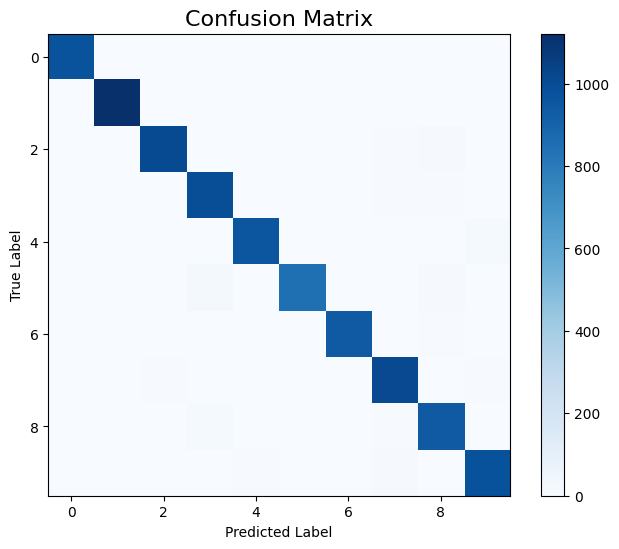

In [ ]:
# ---- Evaluate the best model on the test set ----
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# ---- Predictions ----
y_pred_probs = best_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ---- Classification report ----
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---- Confusion matrix ----
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ---- Plot confusion matrix ----
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()


# Step 8 – Plot training curves (accuracy and loss) for the best model
#
# In this step:
#   • We rebuild the best model using the best hyperparameters from Step 5.
#   • Retrain it on (x_train, y_train) while validating on (x_val, y_val).
#   • Store the training history so we can plot:
#         - accuracy vs epochs  (train & validation)
#         - loss vs epochs      (train & validation)
#
# These plots help us visualize:
#   • Whether the model overfits or underfits.
#   • How well the neural network learned over time.


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8304 - loss: 0.6112 - val_accuracy: 0.9472 - val_loss: 0.1761
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9552 - loss: 0.1490 - val_accuracy: 0.9553 - val_loss: 0.1480
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9713 - loss: 0.0973 - val_accuracy: 0.9580 - val_loss: 0.1412
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9792 - loss: 0.0714 - val_accuracy: 0.9602 - val_loss: 0.1294
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9842 - loss: 0.0540 - val_accuracy: 0.9603 - val_loss: 0.1302
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9882 - loss: 0.0416 - val_accuracy: 0.9635 - val_loss: 0.1292
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9912 - loss: 0.0320 - val_accuracy: 0.9628 - val_loss: 0.1341
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9930 - loss: 0.0257 - val_accuracy: 0.

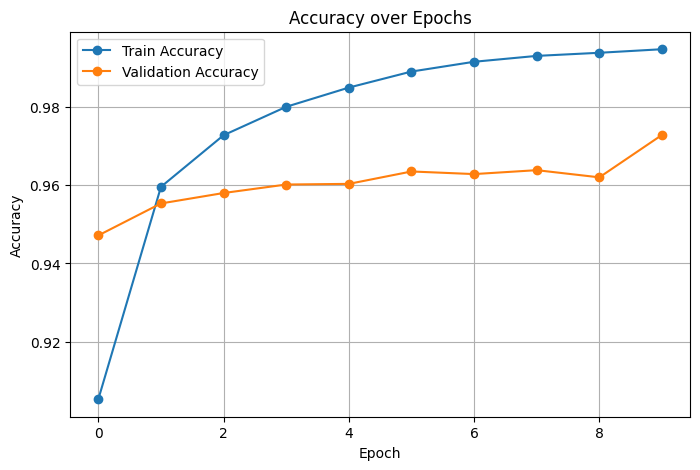

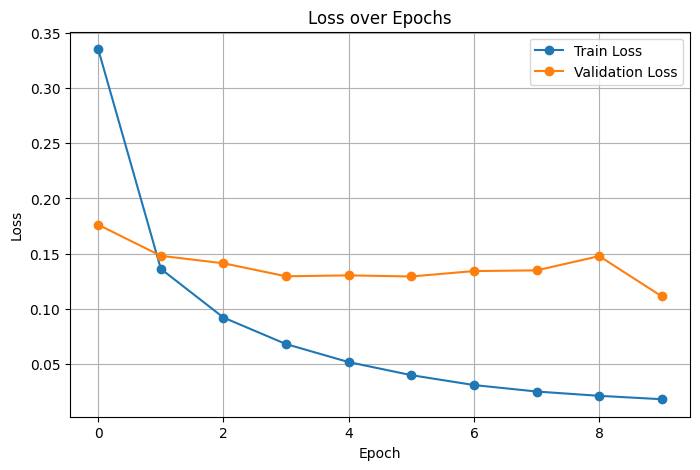

In [ ]:
# ---- Rebuild the best model using best hyperparameters ----
best_model_retrained = build_model(
    hidden_units=best_params["hidden_units"],
    activation=best_params["activation"],
    optimizer=best_params["optimizer"]
)

# ---- Retrain the model to collect training history ----
history = best_model_retrained.fit(
    x_train, y_train,
    batch_size=best_params["batch_size"],
    epochs=best_params["epochs"],
    validation_data=(x_val, y_val),
    verbose=1
)

# ---- Plot Accuracy ----
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy", marker='o')
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker='o')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot Loss ----
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", marker='o')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


# Step 9 – Trying different weight initializations
#
# In the professor's notebook, there is an extra GridSearchCV that tests
# different weight initialization schemes such as:
#   'uniform', 'lecun_uniform', 'normal', 'zero', 'glorot_uniform',
#   'he_normal', 'he_uniform'
#
# Here, we reproduce the same idea using our *manual* grid search pipeline.
#
#  • We fix the other hyperparameters to the best ones we already found:
#       - hidden_units   = best_params["hidden_units"]
#       - activation     = best_params["activation"]
#       - optimizer      = best_params["optimizer"]
#       - batch_size     = best_params["batch_size"]
#       - epochs         = best_params["epochs"]
#  • We only vary the kernel initializer.
#  • For each initializer we:
#       - build a new model with that initializer
#       - train on (x_train, y_train), validate on (x_val, y_val)
#       - record the best validation accuracy
#  • At the end we report which initializer performed best.


In [ ]:
# ---- Define a model builder that accepts an initializer ----
def build_model_with_initializer(hidden_units, activation, optimizer, kernel_initializer):
    # choose optimizer object
    if optimizer == "adam":
        opt = keras.optimizers.Adam()
    elif optimizer == "sgd":
        opt = keras.optimizers.SGD()
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(hidden_units,
                           activation=activation,
                           kernel_initializer=kernel_initializer),
        keras.layers.Dense(hidden_units,
                           activation=activation,
                           kernel_initializer=kernel_initializer),
        keras.layers.Dense(10, activation="softmax",
                           kernel_initializer=kernel_initializer),
    ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=opt,
        metrics=["accuracy"],
    )
    return model


# ---- List of initializers to try (like professor's list) ----
initializers_list = [
    "uniform",
    "lecun_uniform",
    "normal",
    "zeros",
    "glorot_uniform",
    "he_normal",
    "he_uniform",
]

print("Initializers to test:", initializers_list)

# ---- Fix other hyperparameters to the best ones we already found ----
fixed_hidden_units = best_params["hidden_units"]
fixed_activation   = best_params["activation"]
fixed_optimizer    = best_params["optimizer"]
fixed_batch_size   = best_params["batch_size"]
fixed_epochs       = best_params["epochs"]

print("\nUsing fixed hyperparameters:")
print("  hidden_units:", fixed_hidden_units)
print("  activation  :", fixed_activation)
print("  optimizer   :", fixed_optimizer)
print("  batch_size  :", fixed_batch_size)
print("  epochs      :", fixed_epochs)

# ---- Manual search over initializers ----
best_init_name = None
best_init_val_acc = 0.0
results_inits = []

for init_name in initializers_list:
    print(f"\n=== Initializer: {init_name} ===")

    model_init = build_model_with_initializer(
        hidden_units=fixed_hidden_units,
        activation=fixed_activation,
        optimizer=fixed_optimizer,
        kernel_initializer=init_name,
    )

    history_init = model_init.fit(
        x_train,
        y_train,
        batch_size=fixed_batch_size,
        epochs=fixed_epochs,
        validation_data=(x_val, y_val),
        verbose=1,
    )

    val_acc_this = max(history_init.history["val_accuracy"])
    results_inits.append((init_name, val_acc_this))

    print(f"--> Best val_accuracy for initializer '{init_name}': {val_acc_this:.4f}")

    if val_acc_this > best_init_val_acc:
        best_init_val_acc = val_acc_this
        best_init_name = init_name
        best_init_model = model_init  # keep reference to best initializer model

print("\n=== Initializer search completed ===")
print(f"Best initializer: {best_init_name}")
print(f"Best validation accuracy with this initializer: {best_init_val_acc:.4f}")

print("\nAll initializer results:")
for name, acc in results_inits:
    print(f"  {name:15s} -> val_accuracy = {acc:.4f}")


Initializers to test: ['uniform', 'lecun_uniform', 'normal', 'zeros', 'glorot_uniform', 'he_normal', 'he_uniform']

Using fixed hyperparameters:
  hidden_units: 128
  activation  : relu
  optimizer   : adam
  batch_size  : 128
  epochs      : 10

=== Initializer: uniform ===
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7697 - loss: 0.8281 - val_accuracy: 0.9307 - val_loss: 0.2286
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9402 - loss: 0.2083 - val_accuracy: 0.9477 - val_loss: 0.1737
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9594 - loss: 0.1391 - val_accuracy: 0.9568 - val_loss: 0.1473
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9696 - loss: 0.1014 - val_accuracy: 0.9603 - val_loss: 0.1321
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9766 - loss: 0.0767 - val_accuracy: 0.9640 - val_loss: 0.1227
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9819 - loss: 0.059

# Step 10 – Additional visualizations and model saving
#
# In this step, we add optional but useful pieces, similar to the template:
#
#   (A) Display some test images with their predicted labels
#   (B) Show model predictions vs true labels in a nice grid
#   (C) Save the best model architecture to JSON and weights to H5
#
# These features are not required by the assignment, but they match
# the structure and depth of your professor's template and make the
# notebook more complete and polished.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


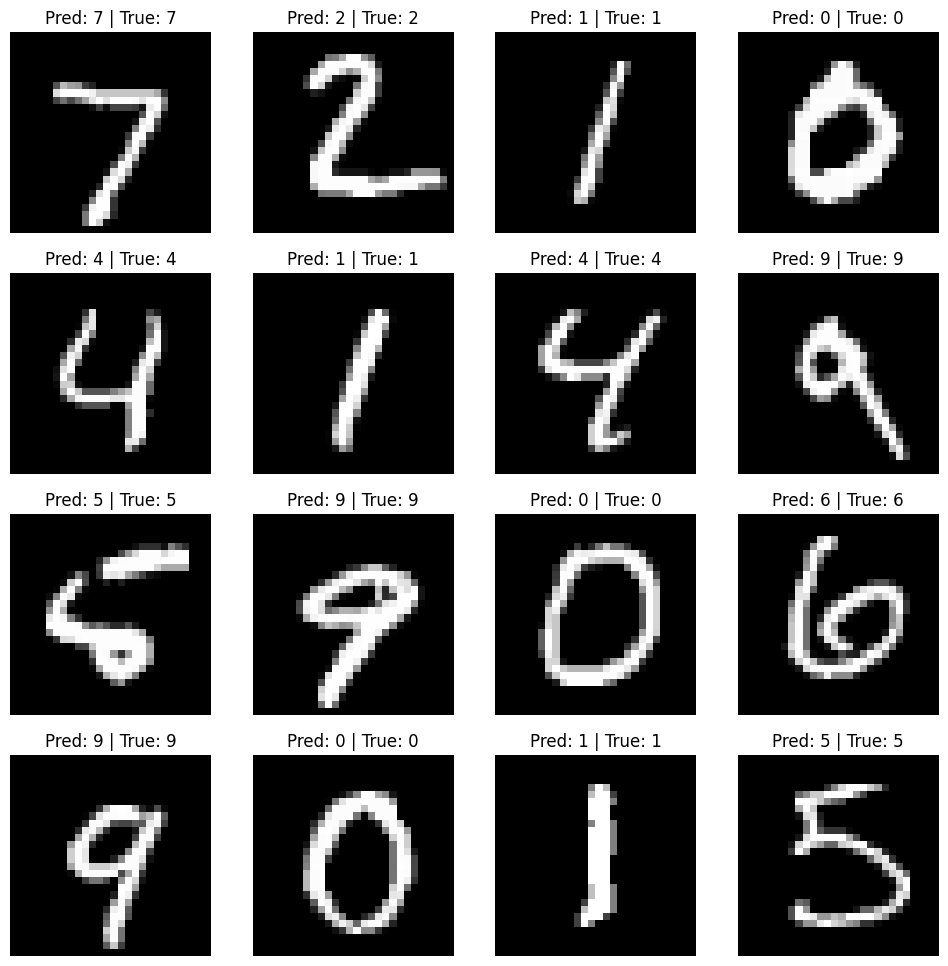

Model saved as:
 - best_mnist_model.json
 - best_mnist.weights.h5


In [ ]:
# ---- (A) Display sample test images + predictions ----

plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    pred_label = np.argmax(best_model_retrained.predict(x_test[i].reshape(1, -1)), axis=1)[0]
    plt.title(f"Pred: {pred_label} | True: {y_test[i]}")
    plt.axis("off")
plt.show()

# ---- (B) Save model architecture + weights ----

# ---- Save model architecture ----
model_json = best_model_retrained.to_json()
with open("best_mnist_model.json", "w") as json_file:
    json_file.write(model_json)

# ---- Save weights (required extension: .weights.h5) ----
best_model_retrained.save_weights("best_mnist.weights.h5")

print("Model saved as:")
print(" - best_mnist_model.json")
print(" - best_mnist.weights.h5")


In [ ]:
import pandas as pd

# Convert results list → DataFrame
results_df = pd.DataFrame(results)

# Sort by best validation accuracy (descending)
results_df = results_df.sort_values(by="best_val_accuracy", ascending=False).reset_index(drop=True)

results_df


,hidden_units,activation,optimizer,batch_size,epochs,best_val_accuracy
0,128,relu,adam,128,10,0.975500
1,128,tanh,adam,128,10,0.974000
2,64,tanh,adam,128,10,0.968500
3,128,tanh,adam,128,5,0.965500
4,128,relu,adam,128,5,0.964167
5,64,relu,adam,128,10,0.963667
6,64,tanh,adam,128,5,0.962000
7,64,relu,adam,128,5,0.958667
8,128,relu,sgd,128,10,0.924333
9,64,relu,sgd,128,10,0.921000


In [ ]:
best_table = results_df.head(1).rename(
    columns={"best_val_accuracy": "val_accuracy"}
)

print("Best hyperparameters (row to put in the report):")
display(best_table)


Best hyperparameters (row to put in the report):


,hidden_units,activation,optimizer,batch_size,epochs,val_accuracy
0,128,relu,adam,128,10,0.9755
